Same stuff from prev notebook

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import time

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels=1, base_channels=32):
        super().__init__()
        self.block1 = ConvBlock(in_channels, base_channels)          # e.g. 1 -> 32
        self.block2 = ConvBlock(base_channels, base_channels * 2)      # 32 -> 64
        self.block3 = ConvBlock(base_channels * 2, base_channels * 4)    # 64 -> 128
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        s1 = self.block1(x)         # skip connection 1, full resolution
        x = self.pool(s1)

        s2 = self.block2(x)          # skip connection 2, half resolution
        x = self.pool(s2)

        s3 = self.block3(x)           # skip connection 3, quarter resolution
        x = self.pool(s3)              # bottleneck input, eighth resolution

        return x, (s1, s2, s3)

class Decoder(nn.Module):
    def __init__(self, base_channels=32):
        super().__init__()

        self.up3 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base_channels * 4 + base_channels * 4, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels * 2 + base_channels * 2, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels + base_channels, base_channels)

        self.out_conv = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x, skips):
        s1, s2, s3 = skips

        x = self.up3(x)
        x = torch.cat([x, s3], dim=1)
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, s2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, s1], dim=1)
        x = self.dec1(x)

        return self.out_conv(x)

class DetectionModel(nn.Module):
    def __init__(self, in_channels=1, base_channels=32):
        super().__init__()
        self.encoder = Encoder(in_channels, base_channels)
        self.decoder = Decoder(base_channels)

    def forward(self, x):
        x, skips = self.encoder(x)
        mask_logits = self.decoder(x, skips)
        return mask_logits

model = DetectionModel(in_channels=1, base_channels=32)
dummy = torch.randn(4, 1, 256, 256)
out = model(dummy)
print(out.shape)   # expect [4, 1, 256, 256]

n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} params")

torch.Size([4, 1, 256, 256])
976,033 params


torch.Size([1, 256, 256]) torch.Size([1, 256, 256])
tensor([0., 1.])


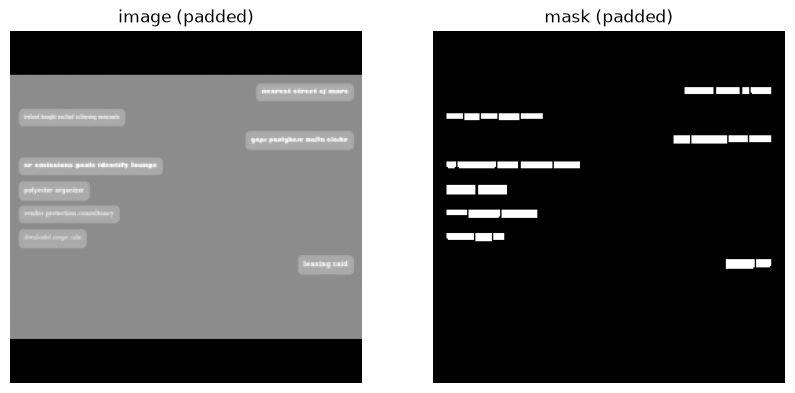

torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256])


In [3]:
import os
import json
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
import torchvision.transforms as T
import matplotlib.pyplot as plt

def resize_with_padding(img, target_size, fill=0):
    """
    Resizes img to fit within target_size while preserving aspect ratio,
    then pads with `fill` to reach the exact target size.
    """
    target_w, target_h = target_size
    w, h = img.size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)

    img_resized = img.resize((new_w, new_h), Image.BILINEAR)

    pad_w = target_w - new_w
    pad_h = target_h - new_h
    padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)

    return ImageOps.expand(img_resized, padding, fill=fill)

def build_detection_transform(img_h=256, img_w=256):
    def transform(img):
        img = resize_with_padding(img, (img_w, img_h), fill=0)
        return T.ToTensor()(img)
    return transform

class DetectionDataset(Dataset):
    def __init__(self, image_dir, mask_dir, n_samples, transform):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.n_samples = n_samples
        self.transform = transform

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img = Image.open(f"{self.image_dir}/{idx:05d}.png").convert('L')
        mask = Image.open(f"{self.mask_dir}/{idx:05d}.png").convert('L')

        img = self.transform(img)
        mask = self.transform(mask)
        mask = (mask > 0.5).float()

        return img, mask

transform = build_detection_transform()
ds = DetectionDataset("../data/detection/train/images", "../data/detection/train/masks", 5000, transform)

img, mask = ds[0]
print(img.shape, mask.shape)   # expect [1, 256, 256] and [1, 256, 256]
print(mask.unique())

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img[0], cmap='gray'); plt.title("image (padded)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(mask[0], cmap='gray'); plt.title("mask (padded)"); plt.axis('off')
plt.show()
loader = DataLoader(ds, batch_size=8, shuffle=True)
imgs, masks = next(iter(loader))
print(imgs.shape, masks.shape) 

device + data

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

transform = build_detection_transform()
ds = DetectionDataset("../data/detection/train/images", "../data/detection/train/masks", 5000, transform)

n = len(ds)
val_size = int(0.1 * n)
generator = torch.Generator().manual_seed(42)
train_ds, val_ds = torch.utils.data.random_split(ds, [n - val_size, val_size], generator=generator)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

cuda


model + optimizer

In [5]:
model = DetectionModel(in_channels=1, base_channels=32).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} params")

976,033 params


Loss function

In [6]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

def combined_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss(logits, targets)
    return bce + dice

sanity check - loss at step 0

In [7]:
imgs, masks = next(iter(train_loader))
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    logits = model(imgs)
    loss = combined_loss(logits, masks)
print(loss.item())

1.5090482234954834


sanity check - overfit a tiny batch

In [8]:
imgs8, masks8 = imgs[:8].to(device), masks[:8].to(device)

model.train()
for step in range(300):
    optimizer.zero_grad()
    logits = model(imgs8)
    loss = combined_loss(logits, masks8)
    loss.backward()
    optimizer.step()
    if step % 30 == 0:
        print(step, loss.item())

0 1.5098472833633423
30 0.9369103908538818
60 0.7323760390281677
90 0.5409209728240967
120 0.3882244825363159
150 0.24679578840732574
180 0.1575416773557663
210 0.10445144027471542
240 0.0742269977927208
270 0.055637091398239136


Training Loop

In [9]:
model = DetectionModel(in_channels=1, base_channels=32).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

def evaluate_loss(model, loader, device):
    model.eval()
    total = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = combined_loss(logits, masks)
            total += loss.item()
    model.train()
    return total / len(loader)

epochs = 20
best_val_loss = float('inf')

start = time.time()
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss = evaluate_loss(model, val_loader, device)
    print(f"epoch {epoch}: train {train_loss:.4f}  val {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "../checkpoints/detection_baseline.pt")

elapsed = time.time() - start
print(f"training time: {elapsed:.1f}s")

epoch 0: train 0.5553  val 0.2467
epoch 1: train 0.1143  val 0.0949
epoch 2: train 0.0681  val 0.0641
epoch 3: train 0.0527  val 0.0513
epoch 4: train 0.0447  val 0.0456
epoch 5: train 0.0372  val 0.0496
epoch 6: train 0.0319  val 0.0330
epoch 7: train 0.0288  val 0.0310
epoch 8: train 0.0266  val 0.0294
epoch 9: train 0.0258  val 0.0323
epoch 10: train 0.0254  val 0.0308
epoch 11: train 0.0233  val 0.0285
epoch 12: train 0.0223  val 0.0265
epoch 13: train 0.0214  val 0.0313
epoch 14: train 0.0208  val 0.0484
epoch 15: train 0.0203  val 0.0255
epoch 16: train 0.0196  val 0.0244
epoch 17: train 0.0199  val 0.0280
epoch 18: train 0.0190  val 0.0250
epoch 19: train 0.0183  val 0.0243
training time: 1755.1s
